# **EE 413: Applied Digital Signal Processing**

##*Project: Image Compression and Classification with Deep Learning*

**Dataset:** *Mini-ImageNet*


**Application of course topics:**

Topic 1:  Wavelet Transform

Topic 2: Convex Optimization

Topic 3: Compressed Sensing

##**Team Members:**

- Ahmad Edrees Al-Eid - 20215490
- Ali Alhajji - 202264620
- Member 3 - ID
- Member 4 - ID

## 1. Model Selection and Baseline Establishment

### Tools and Libraries

In [1]:
import os
from google.colab import drive
import tarfile
import matplotlib.pyplot as plt
import pandas as pd
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

seed_orbit = 413
random.seed(seed_orbit)
np.random.seed(seed_orbit)
torch.manual_seed(seed_orbit)
torch.cuda.manual_seed_all(seed_orbit)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

run_device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", run_device)

ModuleNotFoundError: No module named 'google'

### Load and extract the dataset

In [ ]:
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/EE413/miniimagenet'

train_tar_path = base_path + '/train.tar'
test_tar_path  = base_path + '/test.tar'
val_tar_path   = base_path + '/val.tar'
extract_path = '/content/miniimagenet'
os.makedirs(extract_path, exist_ok=True)


if not os.path.exists('/content/miniimagenet/train'):
    with tarfile.open(train_tar_path, 'r') as tar:
        tar.extractall(extract_path)

if not os.path.exists('/content/miniimagenet/test'):
    with tarfile.open(test_tar_path, 'r') as tar:
        tar.extractall(extract_path)

if not os.path.exists('/content/miniimagenet/val'):
    with tarfile.open(val_tar_path, 'r') as tar:
        tar.extractall(extract_path)

train_dir = '/content/miniimagenet/train'
test_dir  = '/content/miniimagenet/test'
val_dir   = '/content/miniimagenet/val'

Mounted at /content/drive


/tmp/ipykernel_6716/4006935716.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)
/tmp/ipykernel_6716/4006935716.py:17: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)
/tmp/ipykernel_6716/4006935716.py:21: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)


train_dir exists: True
test_dir exists : True
val_dir exists  : True


In [ ]:
img_size = 96
batch_size = 64
val_frac = 0.10
test_frac = 0.10
num_staff = 2

tfm_train = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

tfm_eval = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

ds_train_aug = datasets.ImageFolder(train_dir, transform=tfm_train)
ds_train_eval = datasets.ImageFolder(train_dir, transform=tfm_eval)

all_idx = list(range(len(ds_train_aug)))
all_targets = ds_train_aug.targets

train_idx, temp_idx = train_test_split(
    all_idx,
    test_size=(val_frac + test_frac),
    stratify=all_targets,
    random_state=seed_orbit
)

temp_targets = [all_targets[i] for i in temp_idx]
valid_idx, test_idx = train_test_split(
    temp_idx,
    test_size=(test_frac / (val_frac + test_frac)),
    stratify=temp_targets,
    random_state=seed_orbit
)

set_train = Subset(ds_train_aug, train_idx)
set_valid = Subset(ds_train_eval, valid_idx)
set_test = Subset(ds_train_eval, test_idx)
ldr_train = DataLoader(set_train, batch_size=batch_size, shuffle=True,  num_workers=num_staff, pin_memory=True)
ldr_valid = DataLoader(set_valid, batch_size=batch_size, shuffle=False, num_workers=num_staff, pin_memory=True)
ldr_test = DataLoader(set_test,   batch_size=batch_size, shuffle=False, num_workers=num_staff, pin_memory=True)
class_galaxy = ds_train_aug.classes
n_classes = len(class_galaxy)
print(f"#train={len(set_train)} | #val={len(set_valid)} | #test={len(set_test)} | #classes={n_classes}")
print("first 5 classes:", class_galaxy[:5])

#train=30720 | #val=3840 | #test=3840 | #classes=64
first 5 classes: ['n01532829', 'n01558993', 'n01704323', 'n01749939', 'n01770081']
official train/test class overlap = 0 (expected 0 for few-shot split)


### My training settings

In [ ]:
epoch_budget = 8
lr_res = 0.0003
lr_mob = 0.0004
wd_common = 0.0001
stop_patience = 3
loss_oracle = nn.CrossEntropyLoss()

Hyperparameters used:
epoch_budget = 8
lr_res       = 0.0003
lr_mob       = 0.0004
weight_decay = 0.0001
batch_size   = 64
input_size   = 96 x 96
val strategy = stratified split from train_dir: 80% train, 10% val, 10% test


ResNet-18 Model

In [ ]:
resnet_star = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
res_in = resnet_star.fc.in_features
resnet_star.fc = nn.Linear(res_in, n_classes)
resnet_star = resnet_star.to(run_device)

opt_res = optim.AdamW(resnet_star.parameters(), lr=lr_res, weight_decay=wd_common)
sch_res = optim.lr_scheduler.ReduceLROnPlateau(opt_res, mode='max', factor=0.5, patience=1)

print(resnet_star.fc)
print("ResNet18 trainable params:", sum(p.numel() for p in resnet_star.parameters() if p.requires_grad))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 123MB/s]


Linear(in_features=512, out_features=64, bias=True)
ResNet18 trainable params: 11209344


In [ ]:
res_history = []
best_res_val = 0.0
best_res_state = None
res_patience_counter = 0

for ep in range(1, epoch_budget + 1):
    resnet_star.train()
    ep_train_loss = 0.0
    ep_train_correct = 0
    ep_train_total = 0

    for xb, yb in ldr_train:
        xb = xb.to(run_device, non_blocking=True)
        yb = yb.to(run_device, non_blocking=True)

        opt_res.zero_grad()
        logits = resnet_star(xb)
        loss = loss_oracle(logits, yb)
        loss.backward()
        opt_res.step()

        ep_train_loss += loss.item() * xb.size(0)
        pred = logits.argmax(dim=1)
        ep_train_correct += (pred == yb).sum().item()
        ep_train_total += yb.size(0)

    train_loss_epoch = ep_train_loss / ep_train_total
    train_acc_epoch = ep_train_correct / ep_train_total

    resnet_star.eval()
    ep_val_loss = 0.0
    ep_val_correct = 0
    ep_val_total = 0

    with torch.no_grad():
        for xb, yb in ldr_valid:
            xb = xb.to(run_device, non_blocking=True)
            yb = yb.to(run_device, non_blocking=True)

            logits = resnet_star(xb)
            loss = loss_oracle(logits, yb)

            ep_val_loss += loss.item() * xb.size(0)
            pred = logits.argmax(dim=1)
            ep_val_correct += (pred == yb).sum().item()
            ep_val_total += yb.size(0)

    val_loss_epoch = ep_val_loss / ep_val_total
    val_acc_epoch = ep_val_correct / ep_val_total

    sch_res.step(val_acc_epoch)

    row = {
        "epoch": ep,
        "train_loss": train_loss_epoch,
        "train_acc": train_acc_epoch,
        "val_loss": val_loss_epoch,
        "val_acc": val_acc_epoch,
        "lr_now": opt_res.param_groups[0]["lr"]
    }
    res_history.append(row)

    if val_acc_epoch > best_res_val:
        best_res_val = val_acc_epoch
        best_res_state = {k: v.detach().cpu().clone() for k, v in resnet_star.state_dict().items()}
        res_patience_counter = 0
    else:
        res_patience_counter += 1
        if res_patience_counter >= stop_patience:
            break

if best_res_state is not None:
    resnet_star.load_state_dict(best_res_state)

res_hist_df = pd.DataFrame(res_history)
display(res_hist_df)

[ResNet18] ep 01 | tr_loss 1.5278 tr_acc 0.5926 | val_loss 1.2152 val_acc 0.6617 | lr 3.00e-04
[ResNet18] ep 02 | tr_loss 0.9558 tr_acc 0.7268 | val_loss 1.1043 val_acc 0.6961 | lr 3.00e-04
[ResNet18] ep 03 | tr_loss 0.7393 tr_acc 0.7855 | val_loss 1.0761 val_acc 0.7115 | lr 3.00e-04
[ResNet18] ep 04 | tr_loss 0.5954 tr_acc 0.8224 | val_loss 1.1331 val_acc 0.6966 | lr 3.00e-04
[ResNet18] ep 05 | tr_loss 0.4851 tr_acc 0.8543 | val_loss 1.1663 val_acc 0.7008 | lr 1.50e-04
[ResNet18] ep 06 | tr_loss 0.2508 tr_acc 0.9267 | val_loss 0.9913 val_acc 0.7560 | lr 1.50e-04
[ResNet18] ep 07 | tr_loss 0.1515 tr_acc 0.9568 | val_loss 1.0354 val_acc 0.7531 | lr 1.50e-04
[ResNet18] ep 08 | tr_loss 0.1159 tr_acc 0.9680 | val_loss 1.0791 val_acc 0.7484 | lr 7.50e-05


,epoch,train_loss,train_acc,val_loss,val_acc,lr_now
0,1,1.527763,0.592578,1.215194,0.661719,0.000300
1,2,0.955773,0.726823,1.104344,0.696094,0.000300
2,3,0.739288,0.785514,1.076106,0.711458,0.000300
3,4,0.595359,0.822363,1.133063,0.696615,0.000300
4,5,0.485097,0.854297,1.166305,0.700781,0.000150
5,6,0.250801,0.926660,0.991258,0.755990,0.000150
6,7,0.151526,0.956836,1.035419,0.753125,0.000150
7,8,0.115868,0.967969,1.079051,0.748437,0.000075


In [ ]:
resnet_star.eval()
res_pred = []
res_true = []
res_test_loss_sum = 0.0
res_test_total = 0

with torch.no_grad():
    for xb, yb in ldr_test:
        xb = xb.to(run_device, non_blocking=True)
        yb = yb.to(run_device, non_blocking=True)

        logits = resnet_star(xb)
        loss = loss_oracle(logits, yb)

        res_test_loss_sum += loss.item() * xb.size(0)
        res_test_total += yb.size(0)

        pred = logits.argmax(dim=1)
        res_pred.extend(pred.cpu().numpy().tolist())
        res_true.extend(yb.cpu().numpy().tolist())

res_test_loss = res_test_loss_sum / res_test_total
res_test_acc = accuracy_score(res_true, res_pred)
res_test_f1m = f1_score(res_true, res_pred, average="macro")

print("ResNet18 test_loss:", round(res_test_loss, 4))
print("ResNet18 test_acc :", round(res_test_acc, 4))
print("ResNet18 macro_f1 :", round(res_test_f1m, 4))
print(classification_report(res_true, res_pred, target_names=class_galaxy, digits=3))

ResNet18 test_loss: 0.9869
ResNet18 test_acc : 0.7471
ResNet18 macro_f1 : 0.7473
              precision    recall  f1-score   support

   n01532829      0.822     0.617     0.705        60
   n01558993      0.793     0.767     0.780        60
   n01704323      0.887     0.783     0.832        60
   n01749939      0.815     0.883     0.848        60
   n01770081      0.808     0.700     0.750        60
   n01843383      0.887     0.917     0.902        60
   n01910747      0.867     0.867     0.867        60
   n02074367      0.864     0.850     0.857        60
   n02089867      0.750     0.700     0.724        60
   n02091831      0.649     0.833     0.730        60
   n02101006      0.692     0.750     0.720        60
   n02105505      0.852     0.867     0.860        60
   n02108089      0.629     0.650     0.639        60
   n02108551      0.776     0.750     0.763        60
   n02108915      0.647     0.550     0.595        60
   n02111277      0.692     0.750     0.720        60


MobileNetV3 Model

In [ ]:
mobile_pulse = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
mob_in = mobile_pulse.classifier[-1].in_features
mobile_pulse.classifier[-1] = nn.Linear(mob_in, n_classes)
mobile_pulse = mobile_pulse.to(run_device)

opt_mob = optim.AdamW(mobile_pulse.parameters(), lr=lr_mob, weight_decay=wd_common)
sch_mob = optim.lr_scheduler.ReduceLROnPlateau(opt_mob, mode='max', factor=0.5, patience=1)

print(mobile_pulse.classifier)
print("MobileNetV3-Small trainable params:", sum(p.numel() for p in mobile_pulse.parameters() if p.requires_grad))

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 133MB/s]

Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=64, bias=True)
)
MobileNetV3-Small trainable params: 1583456


In [ ]:
mob_history = []
best_mob_val = 0.0
best_mob_state = None
mob_patience_counter = 0

for ep in range(1, epoch_budget + 1):
    mobile_pulse.train()
    ep_train_loss = 0.0
    ep_train_correct = 0
    ep_train_total = 0

    for xb, yb in ldr_train:
        xb = xb.to(run_device, non_blocking=True)
        yb = yb.to(run_device, non_blocking=True)

        opt_mob.zero_grad()
        logits = mobile_pulse(xb)
        loss = loss_oracle(logits, yb)
        loss.backward()
        opt_mob.step()

        ep_train_loss += loss.item() * xb.size(0)
        pred = logits.argmax(dim=1)
        ep_train_correct += (pred == yb).sum().item()
        ep_train_total += yb.size(0)

    train_loss_epoch = ep_train_loss / ep_train_total
    train_acc_epoch = ep_train_correct / ep_train_total

    mobile_pulse.eval()
    ep_val_loss = 0.0
    ep_val_correct = 0
    ep_val_total = 0

    with torch.no_grad():
        for xb, yb in ldr_valid:
            xb = xb.to(run_device, non_blocking=True)
            yb = yb.to(run_device, non_blocking=True)

            logits = mobile_pulse(xb)
            loss = loss_oracle(logits, yb)

            ep_val_loss += loss.item() * xb.size(0)
            pred = logits.argmax(dim=1)
            ep_val_correct += (pred == yb).sum().item()
            ep_val_total += yb.size(0)

    val_loss_epoch = ep_val_loss / ep_val_total
    val_acc_epoch = ep_val_correct / ep_val_total

    sch_mob.step(val_acc_epoch)

    row = {
        "epoch": ep,
        "train_loss": train_loss_epoch,
        "train_acc": train_acc_epoch,
        "val_loss": val_loss_epoch,
        "val_acc": val_acc_epoch,
        "lr_now": opt_mob.param_groups[0]["lr"]
    }
    mob_history.append(row)

    if val_acc_epoch > best_mob_val:
        best_mob_val = val_acc_epoch
        best_mob_state = {k: v.detach().cpu().clone() for k, v in mobile_pulse.state_dict().items()}
        mob_patience_counter = 0
    else:
        mob_patience_counter += 1
        if mob_patience_counter >= stop_patience:
            break

if best_mob_state is not None:
    mobile_pulse.load_state_dict(best_mob_state)

mob_hist_df = pd.DataFrame(mob_history)
display(mob_hist_df)

[MobileNetV3] ep 01 | tr_loss 1.8535 tr_acc 0.5092 | val_loss 1.2096 val_acc 0.6589 | lr 4.00e-04
[MobileNetV3] ep 02 | tr_loss 1.1031 tr_acc 0.6894 | val_loss 1.0877 val_acc 0.7023 | lr 4.00e-04
[MobileNetV3] ep 03 | tr_loss 0.8943 tr_acc 0.7414 | val_loss 1.0943 val_acc 0.6951 | lr 4.00e-04
[MobileNetV3] ep 04 | tr_loss 0.7506 tr_acc 0.7786 | val_loss 1.0668 val_acc 0.7083 | lr 4.00e-04
[MobileNetV3] ep 05 | tr_loss 0.6334 tr_acc 0.8094 | val_loss 1.0830 val_acc 0.7133 | lr 4.00e-04
[MobileNetV3] ep 06 | tr_loss 0.5431 tr_acc 0.8352 | val_loss 1.1263 val_acc 0.7094 | lr 4.00e-04
[MobileNetV3] ep 07 | tr_loss 0.4751 tr_acc 0.8536 | val_loss 1.1600 val_acc 0.7073 | lr 2.00e-04
[MobileNetV3] ep 08 | tr_loss 0.3163 tr_acc 0.9026 | val_loss 1.1158 val_acc 0.7250 | lr 2.00e-04


,epoch,train_loss,train_acc,val_loss,val_acc,lr_now
0,1,1.853478,0.509212,1.209572,0.658854,0.0004
1,2,1.103099,0.689355,1.087735,0.702344,0.0004
2,3,0.894339,0.741374,1.094274,0.695052,0.0004
3,4,0.750636,0.778613,1.066837,0.708333,0.0004
4,5,0.633417,0.809375,1.083027,0.713281,0.0004
5,6,0.543075,0.835221,1.126307,0.709375,0.0004
6,7,0.475108,0.853581,1.160015,0.707292,0.0002
7,8,0.316292,0.902637,1.115754,0.725000,0.0002


In [ ]:
mobile_pulse.eval()
mob_pred = []
mob_true = []
mob_test_loss_sum = 0.0
mob_test_total = 0

with torch.no_grad():
    for xb, yb in ldr_test:
        xb = xb.to(run_device, non_blocking=True)
        yb = yb.to(run_device, non_blocking=True)

        logits = mobile_pulse(xb)
        loss = loss_oracle(logits, yb)

        mob_test_loss_sum += loss.item() * xb.size(0)
        mob_test_total += yb.size(0)

        pred = logits.argmax(dim=1)
        mob_pred.extend(pred.cpu().numpy().tolist())
        mob_true.extend(yb.cpu().numpy().tolist())

mob_test_loss = mob_test_loss_sum / mob_test_total
mob_test_acc = accuracy_score(mob_true, mob_pred)
mob_test_f1m = f1_score(mob_true, mob_pred, average="macro")

print("MobileNetV3-Small test_loss:", round(mob_test_loss, 4))
print("MobileNetV3-Small test_acc :", round(mob_test_acc, 4))
print("MobileNetV3-Small macro_f1 :", round(mob_test_f1m, 4))
print(classification_report(mob_true, mob_pred, target_names=class_galaxy, digits=3))

MobileNetV3-Small test_loss: 1.1171
MobileNetV3-Small test_acc : 0.726
MobileNetV3-Small macro_f1 : 0.7254
              precision    recall  f1-score   support

   n01532829      0.754     0.717     0.735        60
   n01558993      0.860     0.717     0.782        60
   n01704323      0.880     0.733     0.800        60
   n01749939      0.771     0.900     0.831        60
   n01770081      0.814     0.800     0.807        60
   n01843383      0.898     0.883     0.891        60
   n01910747      0.791     0.883     0.835        60
   n02074367      0.839     0.783     0.810        60
   n02089867      0.705     0.717     0.711        60
   n02091831      0.592     0.700     0.641        60
   n02101006      0.690     0.667     0.678        60
   n02105505      0.823     0.850     0.836        60
   n02108089      0.623     0.550     0.584        60
   n02108551      0.712     0.700     0.706        60
   n02108915      0.566     0.500     0.531        60
   n02111277      0.582     

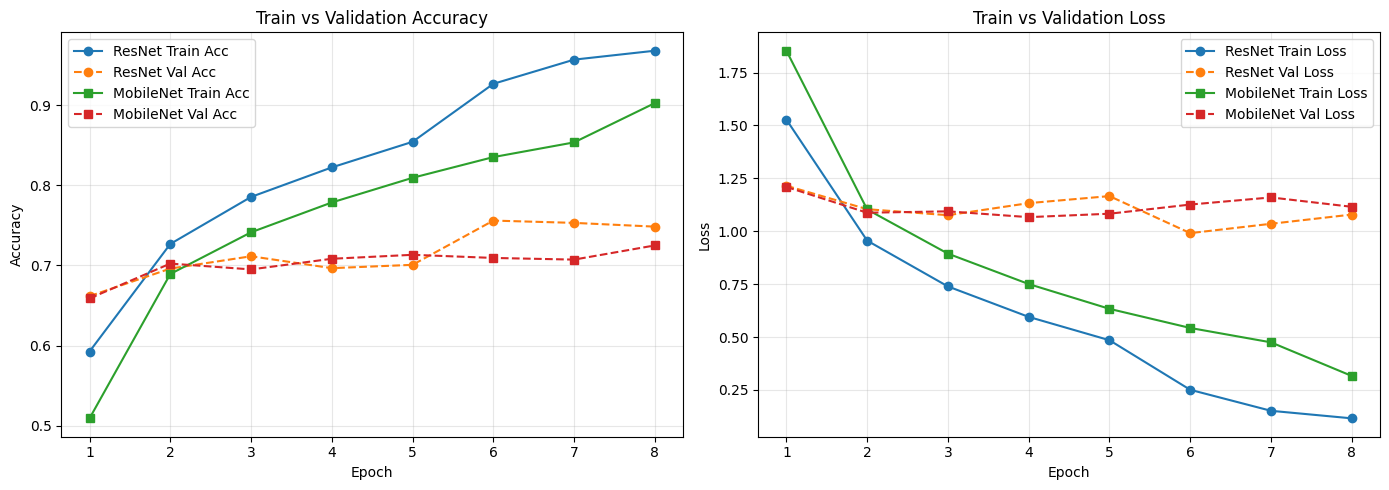

In [ ]:
res_df = pd.DataFrame(res_history)
mob_df = pd.DataFrame(mob_history)

plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
plt.plot(res_df["epoch"], res_df["train_acc"], marker='o', label="ResNet Train Acc")
plt.plot(res_df["epoch"], res_df["val_acc"], marker='o', linestyle='--', label="ResNet Val Acc")
plt.plot(mob_df["epoch"], mob_df["train_acc"], marker='s', label="MobileNet Train Acc")
plt.plot(mob_df["epoch"], mob_df["val_acc"], marker='s', linestyle='--', label="MobileNet Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.grid(alpha=0.3)
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(res_df["epoch"], res_df["train_loss"], marker='o', label="ResNet Train Loss")
plt.plot(res_df["epoch"], res_df["val_loss"], marker='o', linestyle='--', label="ResNet Val Loss")
plt.plot(mob_df["epoch"], mob_df["train_loss"], marker='s', label="MobileNet Train Loss")
plt.plot(mob_df["epoch"], mob_df["val_loss"], marker='s', linestyle='--', label="MobileNet Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


### baseline on uncompressed test set

In [ ]:
params_res = sum(p.numel() for p in resnet_star.parameters())
params_mob = sum(p.numel() for p in mobile_pulse.parameters())

score_card = pd.DataFrame([
    {
        "model": "ResNet18",
        "params_total": params_res,
        "best_val_acc": best_res_val,
        "test_loss": res_test_loss,
        "test_acc": res_test_acc,
        "test_macro_f1": res_test_f1m,
    },
    {
        "model": "MobileNetV3-Small",
        "params_total": params_mob,
        "best_val_acc": best_mob_val,
        "test_loss": mob_test_loss,
        "test_acc": mob_test_acc,
        "test_macro_f1": mob_test_f1m,
    },
])

display(score_card.sort_values("test_acc", ascending=False).reset_index(drop=True))

,model,params_total,best_val_acc,test_loss,test_acc,test_macro_f1
0,ResNet18,11209344,0.75599,0.986886,0.747135,0.747274
1,MobileNetV3-Small,1583456,0.72500,1.117078,0.726042,0.725414


### Saving the models

In [ ]:
save_zone = "/content/drive/MyDrive/EE413/part1_outputs"
os.makedirs(save_zone, exist_ok=True)

torch.save(resnet_star.state_dict(), os.path.join(save_zone, "resnet18_part1_best.pth"))
torch.save(mobile_pulse.state_dict(), os.path.join(save_zone, "mobilenetv3small_part1_best.pth"))
pd.Series(class_galaxy).to_csv(os.path.join(save_zone, "class_names_part1.csv"), index=False)
score_card.to_csv(os.path.join(save_zone, "baseline_metrics_part1.csv"), index=False)

Saved files in: /content/drive/MyDrive/EE413/part1_outputs


## 2. Wavelet-based Image Compression

## 3. Fine-tuning on Compressed Data

In [ ]:
# ── Required imports ──
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
import pywt


def wavelet_compress(img_tensor, threshold=0.1, wavelet='db1', level=2):
    img_np = img_tensor.numpy()
    compressed = np.zeros_like(img_np)
    for c in range(3):
        channel = img_np[c]
        coeffs = pywt.wavedec2(channel, wavelet=wavelet, level=level)
        coeffs_thresh = [coeffs[0]]
        for detail in coeffs[1:]:
            coeffs_thresh.append(
                tuple(pywt.threshold(d, value=threshold, mode='hard') for d in detail)
            )
        recon = pywt.waverec2(coeffs_thresh, wavelet=wavelet)
        recon = recon[:channel.shape[0], :channel.shape[1]]
        compressed[c] = recon
    return torch.tensor(compressed, dtype=torch.float32)

In [ ]:
# --- CELL 1: FINE-TUNING LOOP ---
from torch.utils.data import DataLoader, Dataset
from torchvision import models
from torch import nn, optim

# 1. The Bridge to the wavelet function
class CompressedDataset(Dataset):
    def __init__(self, original_subset, threshold=0.1):
        self.original_subset = original_subset
        self.threshold = threshold
    def __len__(self): 
        return len(self.original_subset)
    def __getitem__(self, idx):
        img, label = self.original_subset[idx]
        compressed_img = wavelet_compress(img, threshold=self.threshold) 
        return compressed_img, label

# 2. Initialize Data 
loss_history = [] # This is needed for the plots cell later
ds_train_comp = CompressedDataset(set_train, threshold=0.1)
ldr_train_comp = DataLoader(ds_train_comp, batch_size=32, shuffle=True, num_workers=2)

# 3. Setup the Model (ResNet-18)
model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model_ft.fc = nn.Linear(model_ft.fc.in_features, n_classes) 
model_ft = model_ft.to(run_device)

# 4. Training Settings
optimizer_ft = optim.AdamW(model_ft.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

# 5. Training Loop
print("Fine-tuning on Compressed Data...")
for epoch in range(1, 4):
    model_ft.train()
    epoch_loss = 0.0
    for images, labels in ldr_train_comp:
        images, labels = images.to(run_device), labels.to(run_device)
        optimizer_ft.zero_grad()
        loss = criterion(model_ft(images), labels)
        loss.backward()
        optimizer_ft.step()
        
        loss_history.append(loss.item()) # Record for the plot cell
        epoch_loss += loss.item()
    print(f"Epoch {epoch} complete. Avg Loss: {epoch_loss/len(ldr_train_comp):.4f}")

In [ ]:
# --- CELL 2: MEASUREMENTS (ACCURACY) ---
model_ft.eval()
correct = 0
total = 0

# Prepare the test loader
ds_test_comp = CompressedDataset(set_test, threshold=0.1)
ldr_test_comp = DataLoader(ds_test_comp, batch_size=batch_size, shuffle=False)

print("Calculating accuracy on compressed test set...")
with torch.no_grad():
    for images, labels in ldr_test_comp:
        images, labels = images.to(run_device), labels.to(run_device)
        outputs = model_ft(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'\nFinal Accuracy of Model 1 on Compressed Images: {100 * correct / total:.2f}%')

In [ ]:
# --- CELL 3: PLOTS ---
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 1. Training Loss Plot
plt.subplot(1, 2, 1)
plt.plot(loss_history, color='tab:red')
plt.title("Fine-tuning Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")

# 2. Visual Comparison Plot
original_img, _ = set_train[0]
compressed_img = wavelet_compress(original_img, threshold=0.1)

plt.subplot(1, 2, 2)
plt.imshow(compressed_img.permute(1, 2, 0).cpu().numpy())
plt.title("Sample: What the Model sees (Compressed)")

plt.tight_layout()
plt.show()